# 問題
国名に関する単語ベクトルに対し、Ward法による階層型クラスタリングを実行せよ。さらに、クラスタリング結果をデンドログラムとして可視化せよ。

In [1]:
def get_word():
    categories1 = ['capital-common-countries', 'capital-world']
    categories2 = ['currency', 'gram6-nationality-adjective']
    countries = set()
    current_category = None
    txt_path = "単語ベクトルの質問.txt"

    with open(txt_path, 'r', encoding='utf-8') as f:
        for row in f:
            row = row.strip()
            if not row:
                continue
            # カテゴリ宣言行
            if row.startswith(':'):
                current_category = row[1:].strip()  
                continue

            # データ行
            parts = row.split()
            if current_category in categories1:
                countries.add(parts[1])  # 2列目の国
                countries.add(parts[3])  # 4列目の国
            elif current_category in categories2:
                countries.add(parts[0])  # 1列目の国

    return list(countries)

from gensim.models import KeyedVectors
def word2vector(countries_list):
  kv_path = "./GoogleNews-vectors-negative300.bin"
  kv = KeyedVectors.load_word2vec_format(kv_path, binary=True)
  country_vec = []
  for country in countries_list:
    if country in kv:
      vec = kv[country] 
      country_vec.append(vec)
    else:
      print("キーが見つかりませんでした:", country)
  return country_vec

countries_vec = word2vector(get_word())

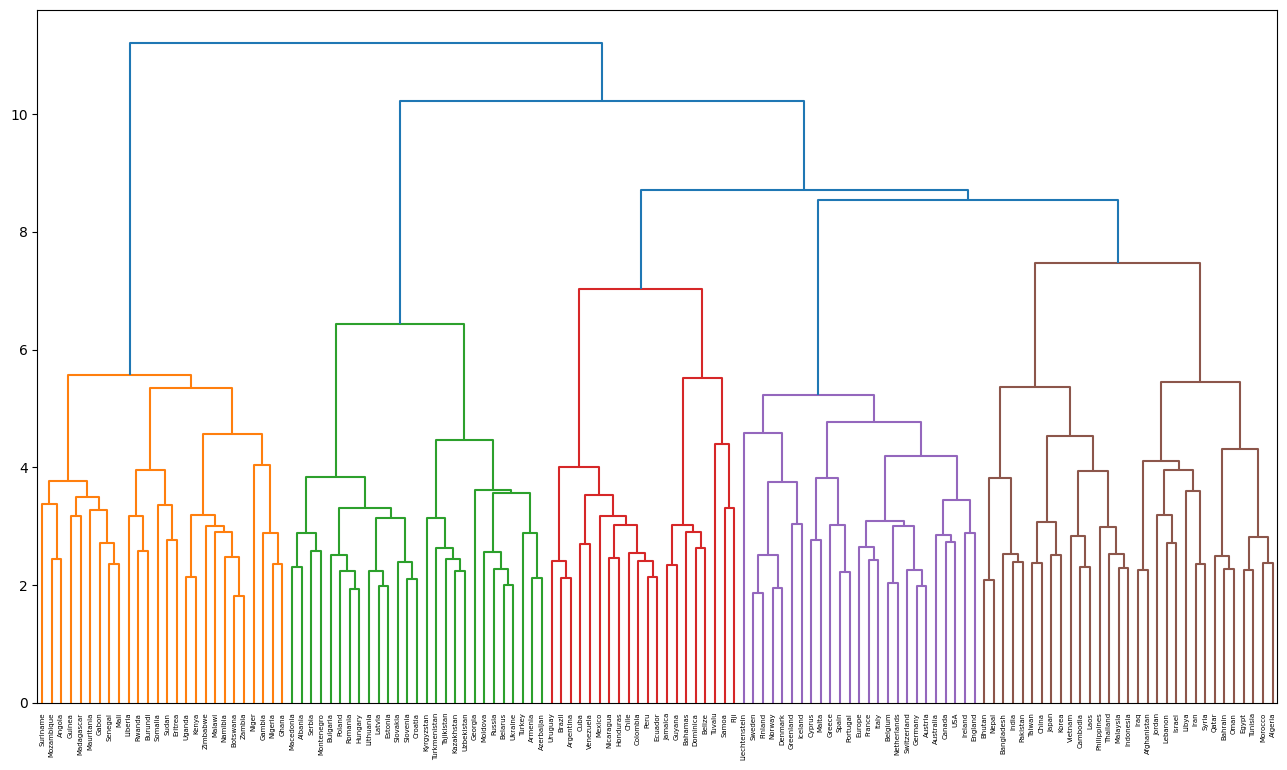

In [6]:
from scipy.cluster.hierarchy import ward, dendrogram
import matplotlib.pyplot as plt

# データのクラスタリング
Z = ward(countries_vec)

# デンドログラムのプロット
plt.figure(figsize=(16, 9))
dendrogram(Z, labels=get_word())
plt.show()

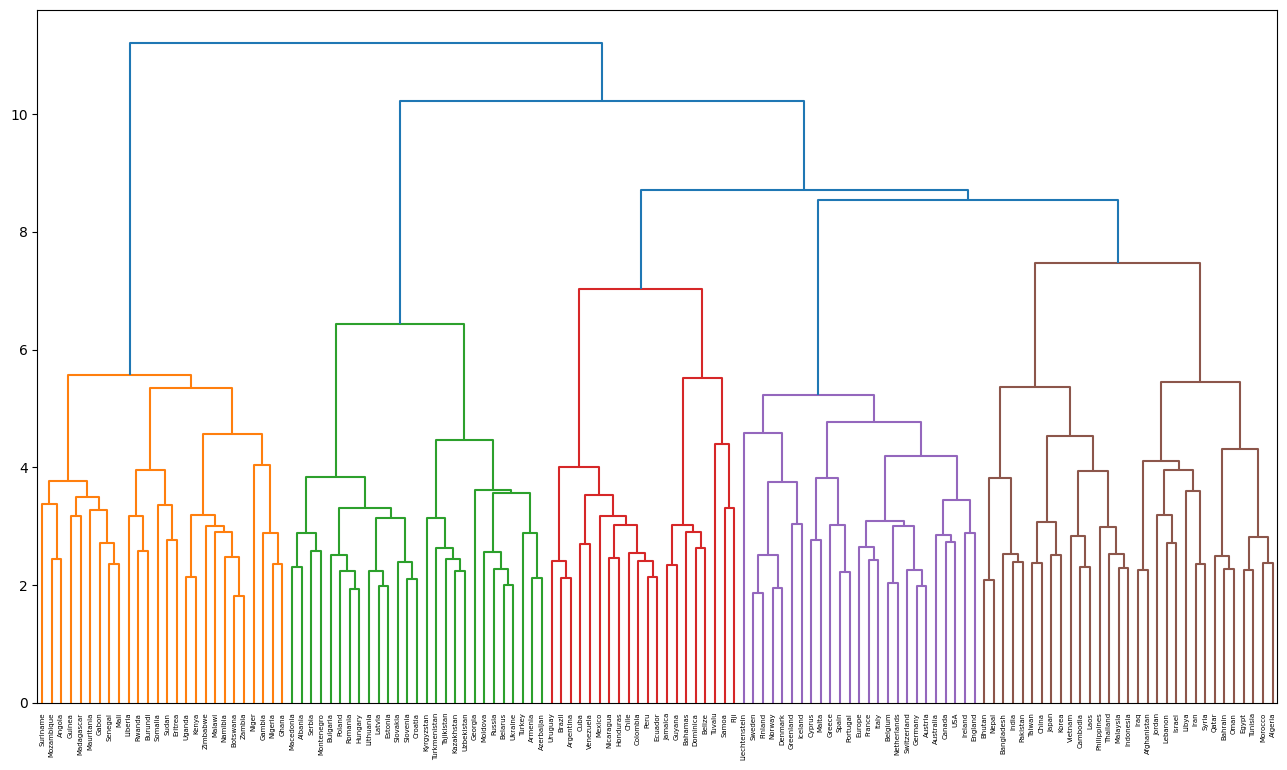

In [4]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

linkage_result = linkage(countries_vec, method='ward')

plt.figure(figsize=(16, 9))
dendrogram(linkage_result, labels=get_word())
plt.show()